# 实验: 图像多目标标签分类 (Multi-label Classification)

**场景**: 智能相册分类、安防监控内容分析  
**数据集**: PASCAL VOC 2007 (真实场景图片)  
**核心模型**: MobileNetV3-Small (轻量级 CNN)

## 1. 实验背景与意义

###  知识点：单标签 vs 多标签
在入门实验中，我们通常做 **Multiclass Classification**（如手写数字），一张图必然属于且仅属于一个类别（Softmax 输出）。

但在现实世界中，图片的内容是复杂的。一张照片可以同时包含 **“人” + “自行车” + “路灯”**。这就是 **Multi-label Classification**。

###  设计意义
1.  **数据处理**：学习如何处理不定长的 XML 标注，并将其转化为固定长度的 **Multi-hot 编码**（如 `[1, 0, 1, 0...]`）。
2.  **模型架构**：使用 **MobileNetV3**，了解轻量级网络如何通过 Depthwise Separable Convolution 减少参数量。
3.  **损失函数**：理解为什么这里不能用 CrossEntropy (Softmax)，而必须用 **BCEWithLogitsLoss (Sigmoid)**。

In [ ]:
# 1. 环境准备与库导入
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms, models, datasets
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from sklearn.metrics import precision_score, recall_score, f1_score

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" 运行设备: {device}")
print(f" PyTorch Version: {torch.__version__}")

🔥 运行设备: cuda
📚 PyTorch Version: 2.5.1+cu121


## 2. 数据集下载与预处理 (Data ETL)

我们将使用 `torchvision.datasets.VOCDetection` 自动下载 PASCAL VOC 2007 数据集。
**难点**：原始数据的标签是 XML 格式的目标检测框。我们需要写一个转换逻辑，只提取“出现了什么类别”，忽略框的位置。

In [ ]:
import os

# 定义 VOC 的 20 个类别
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair',
    'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant',
    'sheep', 'sofa', 'train', 'tvmonitor'
]
class_to_idx = {cls: i for i, cls in enumerate(VOC_CLASSES)}

# -----------------------------------------------------------
# 1. 设定路径 
# -----------------------------------------------------------
# ".." 代表上一级目录，所以 "../data" 指向同级的 data 文件夹
data_root = '../data' 

# 打印一下绝对路径，确认是否正确 (Debug用)
abs_path = os.path.abspath(data_root)
print(f" 数据集路径设定为: {abs_path}")

if not os.path.exists(data_root):
    # 如果 data 文件夹不存在，尝试自动创建
    print(f" 目录不存在，正在创建: {abs_path}")
    os.makedirs(data_root)
else:
    print(" 检测到 data 目录存在")

# -----------------------------------------------------------
# 2. 定义标签转换与预处理
# -----------------------------------------------------------
def encode_labels(target):
    label_tensor = torch.zeros(len(VOC_CLASSES))
    objects = target['annotation']['object']
    if not isinstance(objects, list):
        objects = [objects]
    for obj in objects:
        cls_name = obj['name']
        if cls_name in class_to_idx:
            idx = class_to_idx[cls_name]
            label_tensor[idx] = 1.0
    return label_tensor

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# -----------------------------------------------------------
# 3. 加载数据集
# -----------------------------------------------------------
print("\n 正在加载数据集...")

# 注意：这里 root 参数改成了 data_root
try:
    train_dataset = datasets.VOCDetection(
        root=data_root,           # 指向 ../data
        year='2007', 
        image_set='trainval', 
        download=True,            # 只要 tar 包在 ../data 里，这里会自动解压
        transform=transform, 
        target_transform=encode_labels
    )
    val_dataset = datasets.VOCDetection(
        root=data_root, 
        year='2007', 
        image_set='test', 
        download=True, 
        transform=transform, 
        target_transform=encode_labels
    )
    print(f" 数据集加载完毕! 训练集: {len(train_dataset)} 张, 测试集: {len(val_dataset)} 张")

except RuntimeError as e:
    print("\n 错误：加载失败。")
    print(f"请确保那两个 .tar 文件已经放入了: {abs_path}")
    print("原始报错信息:", e)

# Windows下建议 num_workers=0，如果有显卡且不报错可以尝试改大
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

📂 数据集路径设定为: d:\project2\3--CNN\data
✅ 检测到 data 目录存在

📥 正在加载数据集...
Using downloaded and verified file: ../data\VOCtrainval_06-Nov-2007.tar
Extracting ../data\VOCtrainval_06-Nov-2007.tar to ../data
Using downloaded and verified file: ../data\VOCtest_06-Nov-2007.tar
Extracting ../data\VOCtest_06-Nov-2007.tar to ../data
✅ 数据集加载完毕! 训练集: 5011 张, 测试集: 4952 张


## 3. 数据可视化 (EDA)

在训练前，我们必须查看数据，确保 Multi-hot 标签生成正确。注意观察图片上方列出的多个标签。

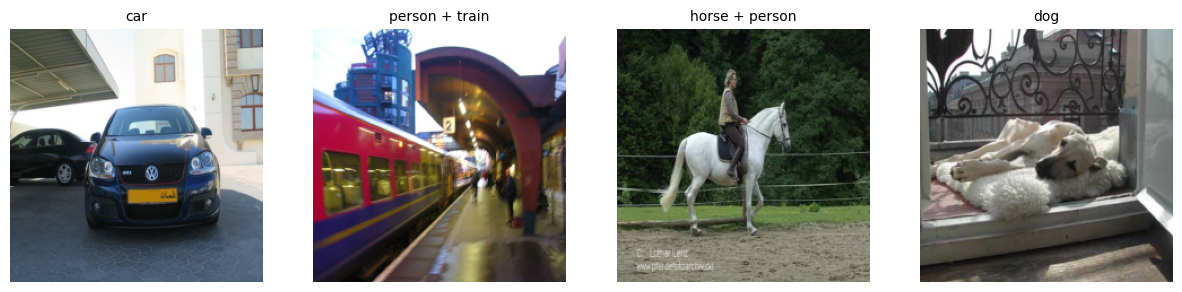

In [5]:
def imshow(tensor, labels):
    # 反归一化以便显示
    tensor = tensor.clone().detach().cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    tensor = tensor * std + mean
    img = tensor.clamp(0, 1).numpy().transpose(1, 2, 0)
    
    # 解析标签
    active_labels = [VOC_CLASSES[i] for i, val in enumerate(labels) if val == 1]
    
    plt.imshow(img)
    plt.title(" + ".join(active_labels), fontsize=10)
    plt.axis('off')

# 随机抽取 4 张图片
data_iter = iter(train_loader)
images, labels = next(data_iter)

plt.figure(figsize=(15, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    imshow(images[i], labels[i])
plt.show()

## 4. 构建轻量级模型 (Lightweight CNN)

我们使用 **MobileNetV3-Small**。这是一个专门为 CPU 和移动端设计的网络，速度极快。

**修改点**：
原始 MobileNet 是为 ImageNet (1000类) 设计的。我们需要将最后一层全连接层 (Classifier) 修改为 **20个输出节点** (对应 VOC 的 20 类)。

In [6]:
print(" 正在构建 MobileNetV3-Small 模型...")
# 加载预训练模型 (Transfer Learning)
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)

# 修改分类头 (Classifier)
# 获取原始输入特征数
in_features = model.classifier[3].in_features
# 替换最后一层 Linear
model.classifier[3] = nn.Linear(in_features, len(VOC_CLASSES))

model = model.to(device)

# 计算参数量
params = sum(p.numel() for p in model.parameters())
print(f" 模型构建完成。参数量: {params/1e6:.2f} M (非常轻量)")

 正在构建 MobileNetV3-Small 模型...


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\86177/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth
100.0%


 模型构建完成。参数量: 1.54 M (非常轻量)


## 5. 模型训练

**关键知识点**：
* **Loss Function**: 使用 `BCEWithLogitsLoss`。它结合了 Sigmoid 和 BCELoss。对于多标签任务，我们把每一个类别都看作一个独立的二分类问题（是猫吗？是狗吗？是车吗？），互不干扰。
* **Learning Rate**: 由于我们使用了预训练模型，建议使用较小的学习率。

In [9]:
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore') # 忽略 0 除警告

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5  # 教学演示为5轮，但实际训练10+更合适
history = {'loss': [], 'f1': []} # 用于记录历史数据

print(" 开始训练 (带实时指标)...")
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # 收集预测结果用于计算 Epoch F1
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())
        
        if i % 50 == 0:
            print(f"   Epoch {epoch+1}, Batch {i}, Loss: {loss.item():.4f}")
            
    # 计算本 Epoch 的平均 Loss
    epoch_loss = running_loss / len(train_loader)
    
    # 计算本 Epoch 的整体 F1 Score (Micro)
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    epoch_f1 = f1_score(all_labels, all_preds, average='micro')
    
    history['loss'].append(epoch_loss)
    history['f1'].append(epoch_f1)
    
    print(f" Epoch [{epoch+1}/{num_epochs}] Finished.")
    print(f"   Avg Loss: {epoch_loss:.4f} | Micro-F1: {epoch_f1:.4f}")

total_time = time.time() - start_time
print(f" 训练完成! 总耗时: {total_time:.1f} 秒")

 开始训练 (带实时指标)...
   Epoch 1, Batch 0, Loss: 0.0602
   Epoch 1, Batch 50, Loss: 0.0717
   Epoch 1, Batch 100, Loss: 0.0559
   Epoch 1, Batch 150, Loss: 0.0726
 Epoch [1/5] Finished.
   Avg Loss: 0.0636 | Micro-F1: 0.8392
   Epoch 2, Batch 0, Loss: 0.0628
   Epoch 2, Batch 50, Loss: 0.0412
   Epoch 2, Batch 100, Loss: 0.0428
   Epoch 2, Batch 150, Loss: 0.0359
 Epoch [2/5] Finished.
   Avg Loss: 0.0472 | Micro-F1: 0.8807
   Epoch 3, Batch 0, Loss: 0.0443
   Epoch 3, Batch 50, Loss: 0.0331
   Epoch 3, Batch 100, Loss: 0.0594
   Epoch 3, Batch 150, Loss: 0.0403
 Epoch [3/5] Finished.
   Avg Loss: 0.0415 | Micro-F1: 0.8983
   Epoch 4, Batch 0, Loss: 0.0452
   Epoch 4, Batch 50, Loss: 0.0299
   Epoch 4, Batch 100, Loss: 0.0533
   Epoch 4, Batch 150, Loss: 0.0529
 Epoch [4/5] Finished.
   Avg Loss: 0.0319 | Micro-F1: 0.9234
   Epoch 5, Batch 0, Loss: 0.0289
   Epoch 5, Batch 50, Loss: 0.0398
   Epoch 5, Batch 100, Loss: 0.0105
   Epoch 5, Batch 150, Loss: 0.0326
 Epoch [5/5] Finished.
   Avg 

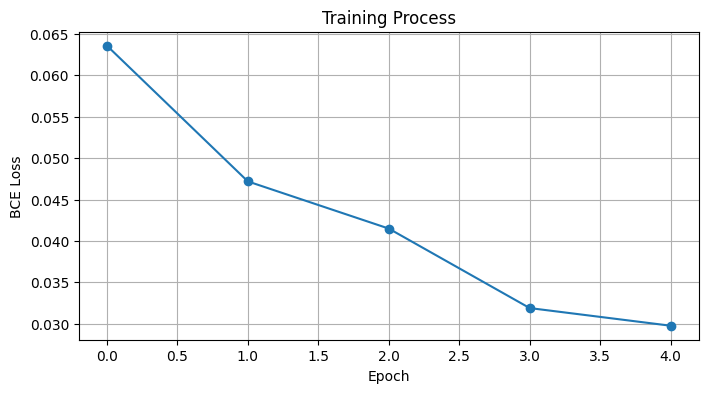

In [11]:
# 绘制损失曲线
plt.figure(figsize=(8, 4))
plt.plot(history['loss'], marker='o', label='Training Loss')
plt.title('Training Process')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.grid(True)
plt.show()

## 6. 训练结果可视化与详细评估

多标签混淆矩阵：由于多标签不能画传统的 N x N 混淆矩阵，我设计了一个 “类别-指标热力图” (Class-wise Performance Heatmap)，能一眼看出哪个类别最难分。

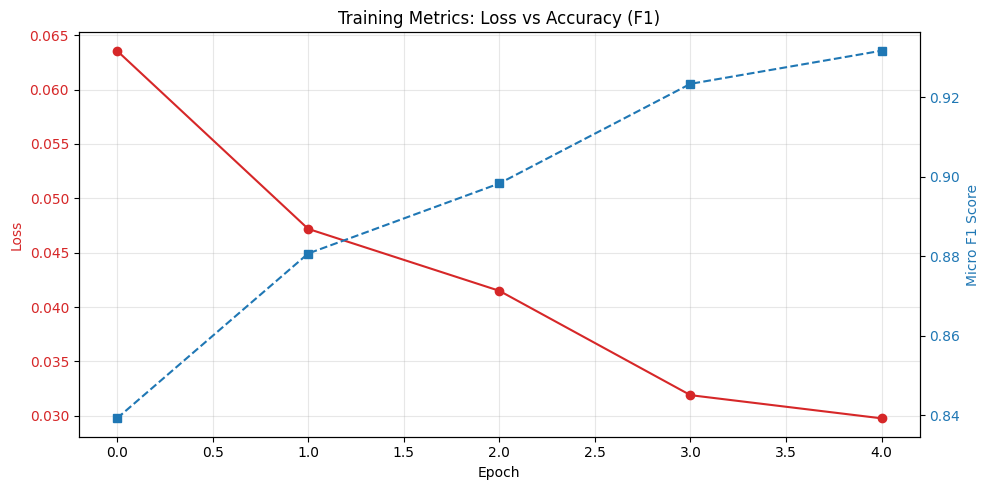

正在计算每个类别的详细指标...


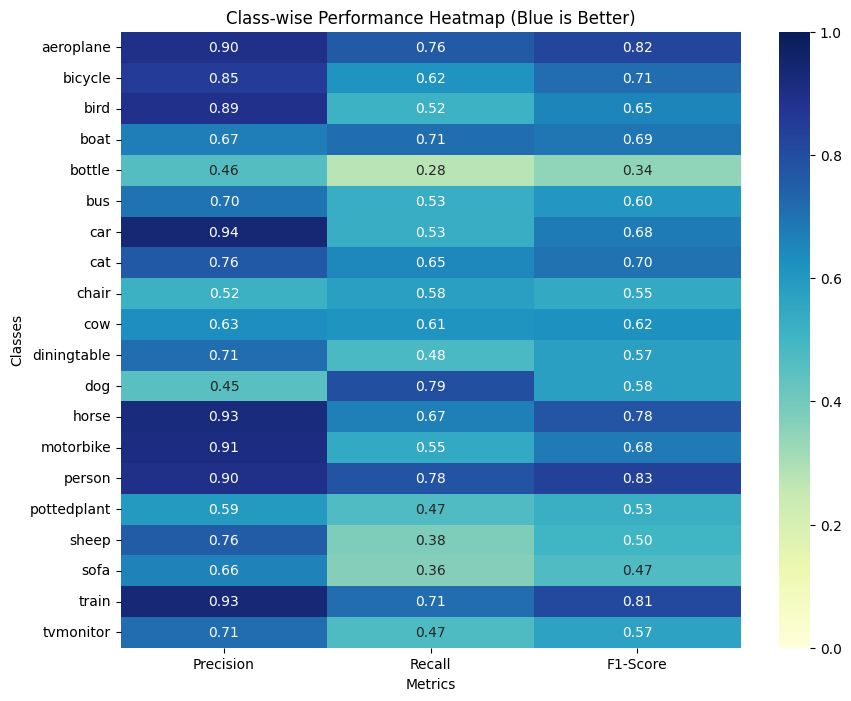

In [12]:
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support

def plot_training_curves(history):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    color = 'tab:red'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color=color)
    ax1.plot(history['loss'], color=color, marker='o', label='Loss')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()  # 创建共享 X 轴的第二个 Y 轴
    color = 'tab:blue'
    ax2.set_ylabel('Micro F1 Score', color=color)
    ax2.plot(history['f1'], color=color, marker='s', linestyle='--', label='F1 Score')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Training Metrics: Loss vs Accuracy (F1)')
    fig.tight_layout()
    plt.show()

def plot_class_performance(model, loader):
    """
    绘制每个类别的 Precision/Recall/F1 热力图
    这是多标签分类中替代 '混淆矩阵' 的最佳方案
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    print("正在计算每个类别的详细指标...")
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            probs = torch.sigmoid(model(inputs))
            preds = (probs > 0.5).float().cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    # 计算每个类别的 P, R, F1
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None)
    
    # 构建 DataFrame 用于绘图
    metrics_df = pd.DataFrame({
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }, index=VOC_CLASSES)
    
    # 绘制热力图
    plt.figure(figsize=(10, 8))
    sns.heatmap(metrics_df, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
    plt.title("Class-wise Performance Heatmap (Blue is Better)")
    plt.ylabel("Classes")
    plt.xlabel("Metrics")
    plt.show()

# 运行可视化
import pandas as pd # 确保导入 pandas
plot_training_curves(history)
plot_class_performance(model, val_loader)

## 7. 模型评估与测试

多标签分类的预测结果是一组概率值（0~1）。我们需要设定一个**阈值 (Threshold)**，通常是 0.5。
* 概率 > 0.5 -> 预测存在该物体
* 概率 <= 0.5 -> 预测不存在

In [13]:
def evaluate_model(model, loader, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []
    
    print("正在评估测试集...")
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)
            
            preds = (probs > threshold).float().cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.numpy())
            
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    # 计算指标
    # Micro-F1: 全局统计所有标签的F1，适合评估整体性能
    f1 = f1_score(all_labels, all_preds, average='micro')
    p = precision_score(all_labels, all_preds, average='micro')
    r = recall_score(all_labels, all_preds, average='micro')
    
    print(f"\n--- 评估结果 (Threshold={threshold}) ---")
    print(f"Precision (查准率): {p:.4f}")
    print(f"Recall    (查全率): {r:.4f}")
    print(f"F1 Score  (综合分): {f1:.4f}")
    return all_preds, all_labels

preds, targets = evaluate_model(model, val_loader)

正在评估测试集...

--- 评估结果 (Threshold=0.5) ---
Precision (查准率): 0.7506
Recall    (查全率): 0.6245
F1 Score  (综合分): 0.6817


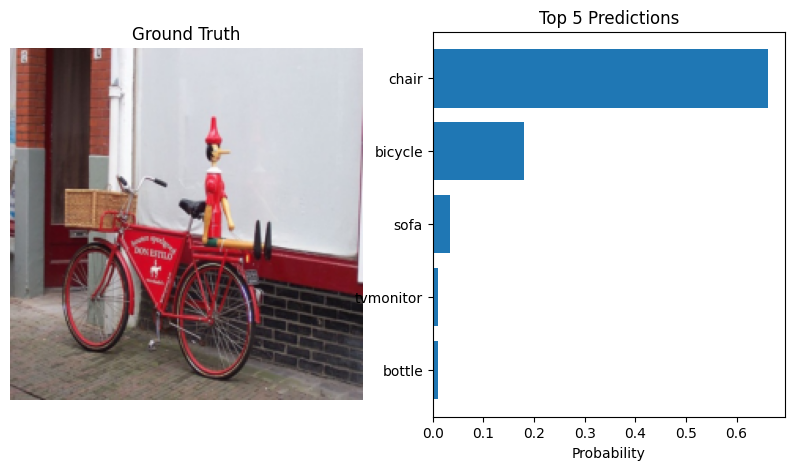

In [15]:
# 可视化预测结果
model.eval()
img, label = val_dataset[10] # 随机取一张测试图
input_tensor = img.unsqueeze(0).to(device)

with torch.no_grad():
    out = model(input_tensor)
    prob = torch.sigmoid(out)[0].cpu().numpy()

# 打印 Top-5 预测概率
top_indices = prob.argsort()[-5:][::-1]

plt.figure(figsize=(10, 5))

ax1 = plt.subplot(1, 2, 1)
imshow(img, label)
ax1.set_title("Ground Truth")

ax2 = plt.subplot(1, 2, 2)
y_pos = np.arange(5)
ax2.barh(y_pos, prob[top_indices], align='center')
ax2.set_yticks(y_pos)
ax2.set_yticklabels([VOC_CLASSES[i] for i in top_indices])
ax2.invert_yaxis()
ax2.set_xlabel('Probability')
ax2.set_title('Top 5 Predictions')
plt.show()

## 8. 交互式随机测试

使用 ipywidgets 制作一个“随机抽查”按钮，点击即可实时推理并显示结果。

In [16]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import random

# 定义按钮和输出区域
btn = widgets.Button(
    description=' 随机抽取一张测试',
    button_style='primary', # 'success', 'info', 'warning', 'danger' or ''
    icon='camera',
    layout=widgets.Layout(width='200px', height='40px')
)

output = widgets.Output()

def predict_random_image(b):
    with output:
        clear_output() # 清除上一次的显示
        
        # 1. 随机取数据
        idx = random.randint(0, len(val_dataset)-1)
        img_tensor, label_true = val_dataset[idx]
        
        # 2. 推理
        model.eval()
        input_tensor = img_tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(input_tensor)
            probs = torch.sigmoid(logits)[0].cpu().numpy()
            
        # 3. 解析结果
        # 真实标签
        true_indices = np.where(label_true.numpy() == 1)[0]
        true_names = [VOC_CLASSES[i] for i in true_indices]
        
        # 预测标签 (Top 5 概率)
        top_indices = probs.argsort()[-5:][::-1]
        top_probs = probs[top_indices]
        top_names = [VOC_CLASSES[i] for i in top_indices]
        
        # 4. 可视化绘图
        plt.figure(figsize=(12, 5))
        
        # 左图：原始图片
        ax1 = plt.subplot(1, 2, 1)
        # 反归一化
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_show = img_tensor.cpu().numpy().transpose(1, 2, 0)
        img_show = std * img_show + mean
        img_show = np.clip(img_show, 0, 1)
        
        ax1.imshow(img_show)
        ax1.set_title(f"Ground Truth: {', '.join(true_names) if true_names else 'None'}", 
                      color='green', fontsize=12, fontweight='bold')
        ax1.axis('off')
        
        # 右图：概率柱状图
        ax2 = plt.subplot(1, 2, 2)
        colors = ['green' if name in true_names else 'gray' for name in top_names]
        bars = ax2.barh(np.arange(5), top_probs, color=colors, alpha=0.7)
        ax2.set_yticks(np.arange(5))
        ax2.set_yticklabels(top_names, fontsize=11)
        ax2.invert_yaxis() # 概率高的在上面
        ax2.set_xlabel('Confidence Score (Probability)')
        ax2.set_xlim(0, 1.1)
        ax2.set_title('Top 5 Predictions (Green = Correct)', fontsize=12)
        
        # 在柱子上标数值
        for i, v in enumerate(top_probs):
            ax2.text(v + 0.02, i, f"{v:.2f}", color='black', va='center')
            
        plt.tight_layout()
        plt.show()

# 绑定点击事件
btn.on_click(predict_random_image)

# 显示组件
print("⬇ 点击下方按钮进行测试：")
display(btn, output)

⬇ 点击下方按钮进行测试：


Button(button_style='primary', description=' 随机抽取一张测试', icon='camera', layout=Layout(height='40px', width='200…

Output()

## 9. 学生拓展与思考

###  思考题

1.  **关于激活函数**：
    如果我不小心把 Loss 函数换成了 `CrossEntropyLoss`，模型还能训练吗？它的输出会变成什么逻辑？（提示：Softmax 具有排他性）。

2.  **关于阈值选择**：
    在代码中我们固定了 `threshold = 0.5`。对于安防场景（宁可错杀一千，不可放过一个坏人），你应该调高还是调低这个阈值？

###  解答思路

<details>
<summary><strong>点击查看参考答案</strong></summary>

#### 1. CrossEntropy vs BCE
* 如果使用 CrossEntropyLoss，模型会尝试在 20 个类别中选出 **概率最大这一个**，压低其他类别的概率。对于包含“人+车”的图片，模型会感到困惑，不知道该预测人还是车，最终导致多目标识别失败。

#### 2. 阈值调整
* **安防场景 (高召回率需求)**：应该 **调低** 阈值（例如 0.3）。只要有一点点像坏人，就先报警，让人工去核查。这会提高 Recall，但也会增加误报。
* **相册分类 (高准确率需求)**：应该 **调高** 阈值（例如 0.7）。必须非常有把握才打上标签，以免用户觉得智能相册很蠢。

</details>